`CELL 01`

# Demographic Fairness in Face-Attribute Recognition under Data Scarcity

**Project 16 - Summer 2026 · Kaggle · InsightFace (ArcFace R100) · scikit-learn**

---

## 1. The question in one sentence
Modern face models report very high *average* accuracy - but does that average hide systematically worse
performance on demographic groups that are **rare in the training data**? This project measures that hidden
gap rigorously, shows exactly where it lives, and tests three cheap ways to shrink it.

## 2. What we actually build (the methodology, end to end)
We deliberately keep the heavy part frozen and learn only a tiny part, so the whole study is fast,
reproducible on a single Kaggle GPU, and isolates the question of *representation fairness*.

1. **Backbone (frozen):** every face image is passed once through **ArcFace R100** (InsightFace's
   `buffalo_l` recognition model, trained on millions of identities). This yields a **512-dimensional
   embedding** per face. We never fine-tune this network - it is a fixed feature extractor. Because the
   embeddings are computed once, all downstream tasks share them for free.
2. **Heads (learned):** on top of the frozen embeddings we train three small **MLP classifiers**
   (256 → 64, ReLU), one per attribute:
   - **Gender** - binary (Female / Male)
   - **Age** - 9 ordinal bins (0-2 … "more than 70")
   - **Race** - 7 classes (Black, East Asian, Indian, Latino_Hispanic, Middle Eastern, Southeast Asian, White)
3. **Fairness axis:** we group every face into an intersectional **`race × age` cell** (7 × 9 = 63 cells)
   and label each cell **under-** or **well-represented** by how often it appears in *training*. Fairness is
   then defined as the **accuracy gap between the under- and well-represented cohorts**.
4. **Robust measurement:** we report the gap two ways - (a) a **pooled, instance-level** gap on the natural
   distribution with a **bootstrap 95% confidence interval**, and (b) a **balanced** gap computed on a
   re-split where every subgroup contributes exactly 50 evaluation samples, so noisy tiny cells cannot
   distort the result. We also correlate per-cell training frequency with per-cell accuracy
   (**Spearman**) to test the scarcity hypothesis directly.
5. **Joint task (4th result):** for each face we also ask whether **all three** attributes are correct at
   once ("3/3"). This compounds per-task errors and is the most operationally meaningful fairness view.
6. **Three mitigations**, each evaluated on the same balanced split so improvements are comparable:
   - **(V2) Reweighting** - oversample rare cells during training.
   - **(ii) Flip Test-Time Augmentation (TTA)** - average the original and horizontally-flipped embedding.
   - **(iii) Age-region group-expert heads** - a gate routes each face to a head specialized for its age
     region (young / middle / old).

## 3. Why these choices
- **Frozen backbone, light heads:** the research question is about the *representation*, not about maximum
  accuracy; freezing keeps the experiment cheap and the comparison clean.
- **Scarcity, not gender balance, as the axis:** FairFace is ~50/50 on gender, so a gender-only fairness
  axis carries almost no signal. The real imbalance is in the `race × age` cells.
- **Three tasks side by side:** a single task can mislead. Comparing gender, age and race reveals that
  "fairness" is **not one property of a model - it is an interaction between the task and the subgroup.**
- **Balanced + bootstrap:** the under-represented cohort is small and noisy; without these robustness
  steps a real gap can be buried under measurement noise (we show exactly this happening).

## 4. Why it matters
Face-attribute systems run in moderation, analytics and access control. If accuracy silently drops for
under-represented groups, the system encodes a measurable demographic bias even when its headline number
looks excellent. This notebook quantifies that gap with defensible statistics, locates it (the age
extremes), and establishes what cheap, head-only mitigations can and cannot fix - without overclaiming.

> **How to read this notebook.** Each section starts with a short *Goal / What it does / Why* note so a
> reader new to the topic can follow the reasoning, not just the code. Every cell is tagged `CELL NN`.


`CELL 02`

## Section 0 - Environment Setup

**Goal:** install the libraries and, above all, make sure the heavy ArcFace inference runs on the **GPU**.

**What it does:** installs InsightFace (the ArcFace backbone), a GPU build of ONNX Runtime, OpenCV, and
`gdown` (for the dataset). Then it verifies the GPU is actually visible.

**Why the care about the GPU:** InsightFace executes ONNX models. If the CPU build of `onnxruntime` is
present it *silently shadows* the GPU build, and embedding extraction for ~98k images crawls on CPU
(10-20× slower). Two defenses: we **pin `onnxruntime-gpu==1.19.2`** (the version that matches Kaggle's
current CUDA image) and we **import `torch` before `onnxruntime`** so PyTorch preloads the CUDA/cuDNN
shared libraries that ONNX needs. CELL 04 then *asserts* the CUDA provider is available and stops early
if it is not.

> If the provider check fails: run the install cell, then **Run → Restart Kernel**, then continue - a
> freshly pip-installed runtime only loads cleanly after a kernel restart.

**Kaggle settings:** Accelerator = `GPU T4 x2` / `P100`, Internet = `On`, Persistence = `Files`.


In [1]:
# ===================== CELL 03 =====================
# Pinned GPU stack (1.19.2 matches Kaggle's CUDA image; latest builds often fail to load on Kaggle).
!pip uninstall -y onnxruntime onnxruntime-gpu >/dev/null 2>&1
!pip install -q insightface onnxruntime-gpu==1.19.2 opencv-python-headless gdown
!pip install -q fairlearn
print("Install step finished. If the next cell fails, Restart the kernel and re-run from there.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/226.2 MB ? eta -:--:--

   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/226.2 MB 50.5 MB/s eta 0:00:05

   ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/226.2 MB 127.7 MB/s eta 0:00:02

   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.8/226.2 MB 213.3 MB/s eta 0:00:01

   ━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/226.2 MB 241.6 MB/s eta 0:00:01

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 18.7/18.7 MB 258.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.9 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/135.5 kB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.0 MB/s eta 0:00:00


Install step finished. If the next cell fails, Restart the kernel and re-run from there.


In [2]:
# ===================== CELL 04 =====================
# Import torch FIRST so it preloads CUDA/cuDNN; then verify ONNX sees the GPU.
import torch
import onnxruntime as ort
try:
    ort.preload_dlls()          # available in ORT >= 1.21; harmless if missing
except Exception as e:
    print("preload_dlls not available:", e)

print("ORT version            :", ort.__version__)
print("PyTorch CUDA available :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU device             :", torch.cuda.get_device_name(0))
print("ONNX Runtime providers :", ort.get_available_providers())

if 'CUDAExecutionProvider' not in ort.get_available_providers():
    raise AssertionError(
        "CUDAExecutionProvider missing. FIX: ensure the install cell finished, then "
        "Run -> Restart Kernel and run from this cell again.")
print(">> ONNX Runtime can use the GPU.")

preload_dlls not available: module 'onnxruntime' has no attribute 'preload_dlls'
ORT version            : 1.19.2
PyTorch CUDA available : True
GPU device             : Tesla T4
ONNX Runtime providers : ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
>> ONNX Runtime can use the GPU.


`CELL 05`

### 0.3 Download the Data (official dchen236/FairFace Google Drive links)

**Goal:** obtain the FairFace images and labels.

**What it does:** the GitHub repository hosts *no data* - the images and label CSVs live on Google Drive.
This cell pulls them with `gdown` and sets three variables used everywhere after: `BASE_DIR` (image root),
`TRAIN_CSV`, `VAL_CSV`. The image archive is the **Padding=0.25** crop version (~550 MB) and unzips into
`train/` and `val/` folders.

**Why these files:** FairFace provides ~86.7k training and ~11k validation faces with `age`, `gender`,
`race` and a `service_test` flag. The 0.25-padding crops are tight, face-centered images well suited to
ArcFace.

> If Drive returns *"quota exceeded"* (this archive is heavily downloaded), download it manually, upload it
> to Kaggle, **skip this cell**, and point the three path variables at your upload.


In [3]:
# ===================== CELL 06 =====================
import os, zipfile, glob
import gdown

WORK = '/kaggle/working/fairface'
os.makedirs(WORK, exist_ok=True)

TRAIN_CSV = f'{WORK}/fairface_label_train.csv'
VAL_CSV   = f'{WORK}/fairface_label_val.csv'
if not os.path.exists(TRAIN_CSV):
    gdown.download(id='1i1L3Yqwaio7YSOCj7ftgk8ZZchPG7dmH', output=TRAIN_CSV, quiet=False)
if not os.path.exists(VAL_CSV):
    gdown.download(id='1wOdja-ezstMEp81tX1a-EYkFebev4h7D', output=VAL_CSV, quiet=False)

BASE_DIR = WORK
if not os.path.exists(f'{WORK}/train'):
    zpath = f'{WORK}/imgs.zip'
    gdown.download(id='1Z1RqRo0_JiavaZw2yzZG6WETdZQ8qX86', output=zpath, quiet=False)
    with zipfile.ZipFile(zpath) as z:
        z.extractall(WORK)
    os.remove(zpath)

print("WORK contents:", os.listdir(WORK)[:10])

Downloading...
From: https://drive.google.com/uc?id=1i1L3Yqwaio7YSOCj7ftgk8ZZchPG7dmH
To: /kaggle/working/fairface/fairface_label_train.csv


  0%|          | 0.00/3.79M [00:00<?, ?B/s]

100%|██████████| 3.79M/3.79M [00:00<00:00, 234MB/s]

Downloading...
From: https://drive.google.com/uc?id=1wOdja-ezstMEp81tX1a-EYkFebev4h7D
To: /kaggle/working/fairface/fairface_label_val.csv


  0%|          | 0.00/448k [00:00<?, ?B/s]

...

 87%|████████▋ | 506M/578M [00:03<00:00, 139MB/s]

 92%|█████████▏| 533M/578M [00:03<00:00, 164MB/s]

 96%|█████████▌| 554M/578M [00:03<00:00, 168MB/s]

100%|██████████| 578M/578M [00:03<00:00, 171MB/s]

WORK contents: ['fairface_label_train.csv', 'fairface_label_val.csv', 'val', 'train']


In [4]:
# ===================== CELL 07 =====================
# Verify all three paths exist before proceeding.
for name, p in [('BASE_DIR', BASE_DIR), ('TRAIN_CSV', TRAIN_CSV), ('VAL_CSV', VAL_CSV)]:
    if not os.path.exists(p):
        print("!! MISSING:", name, "->", p)
        raise FileNotFoundError(f"{name} path is wrong; fix it or upload data manually.")
print("All paths OK ->", os.listdir(BASE_DIR)[:6])

All paths OK -> ['fairface_label_train.csv', 'fairface_label_val.csv', 'val', 'train']


`CELL 08`

## Section 1 - Data, EDA, and the Scarcity Definition

**Goal:** load the labels, confirm the data is clean, understand the class balance, and - the heart of the
whole study - build the intersectional `race × age` subgroup and flag each subgroup as **under-** or
**well-represented**.

**What it does:** reads the two CSVs, checks for missing values, prints the exact class sets (note race is
**7-class** in this archive), plots the label distributions, then forms the 63 `race × age` cells and marks
the rarest third (by *training* count) as under-represented.

**Why it matters:** every fairness number later in the notebook is defined relative to this scarcity flag.
Gender being near-balanced is precisely why we do *not* use gender as the fairness axis; the meaningful
imbalance is in the intersectional cells (infants and the elderly of certain races are rare).

**Label columns:** `file, age, gender, race, service_test`.


In [5]:
# ===================== CELL 09 =====================
import pandas as pd

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
print("train:", train_df.shape, "| val:", val_df.shape)
train_df.head()

train: (86744, 5) | val: (10954, 5)


,file,age,gender,race,service_test
0,train/1.jpg,50-59,Male,East Asian,True
1,train/2.jpg,30-39,Female,Indian,False
2,train/3.jpg,3-9,Female,Black,False
3,train/4.jpg,20-29,Female,Indian,True
4,train/5.jpg,20-29,Female,Indian,True


`CELL 10`

**Path resolution (auto-healing).**

**What it does:** the CSV `file` column may be stored as `train/1.jpg` in one archive or just `1.jpg` in
another. This cell detects the correct way to turn a `file` value into an absolute path *once* and exposes
a single helper `PATH_FN(file)`.

**Why:** every later cell that reads an image (sample grids, embedding extraction, error-analysis faces)
calls `PATH_FN`, so a single resolution point prevents path bugs and makes the notebook portable across the
different FairFace archives.


In [6]:
# ===================== CELL 11 =====================
sample_file = train_df['file'].iloc[0]
cand_a = os.path.join(BASE_DIR, sample_file)
cand_b = os.path.join(BASE_DIR, os.path.basename(sample_file))
if os.path.exists(cand_a):
    PATH_FN = lambda f: os.path.join(BASE_DIR, f)
elif os.path.exists(cand_b):
    PATH_FN = lambda f: os.path.join(BASE_DIR, os.path.basename(f))
else:
    raise FileNotFoundError(f"Image not found. Tried {cand_a} | {cand_b}")
assert os.path.exists(PATH_FN(train_df['file'].iloc[0]))
assert os.path.exists(PATH_FN(val_df['file'].iloc[0]))
print("Image path scheme verified. Example:", PATH_FN(sample_file))

Image path scheme verified. Example: /kaggle/working/fairface/train/1.jpg


In [7]:
# ===================== CELL 12 =====================
# Integrity + label inventory (race is 7-class in this archive).
assert train_df.isnull().sum().sum() == 0 and val_df.isnull().sum().sum() == 0
print("Race  :", sorted(train_df['race'].unique()))
print("Age   :", sorted(train_df['age'].unique()))
print("Gender:", sorted(train_df['gender'].unique()))

Race  : ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']
Age   : ['0-2', '10-19', '20-29', '3-9', '30-39', '40-49', '50-59', '60-69', 'more than 70']
Gender: ['Female', 'Male']


`CELL 13`

**Distribution plots.**

**What it does:** bar charts of the `race`, `gender` and `age` counts in the training set.

**Why:** they make the core motivation visible at a glance - gender is roughly 50/50 (a weak fairness
axis), whereas age is uneven, and once age is crossed with race the resulting 63 cells vary enormously in
size. Those small cells are the under-represented groups whose accuracy we will scrutinize.


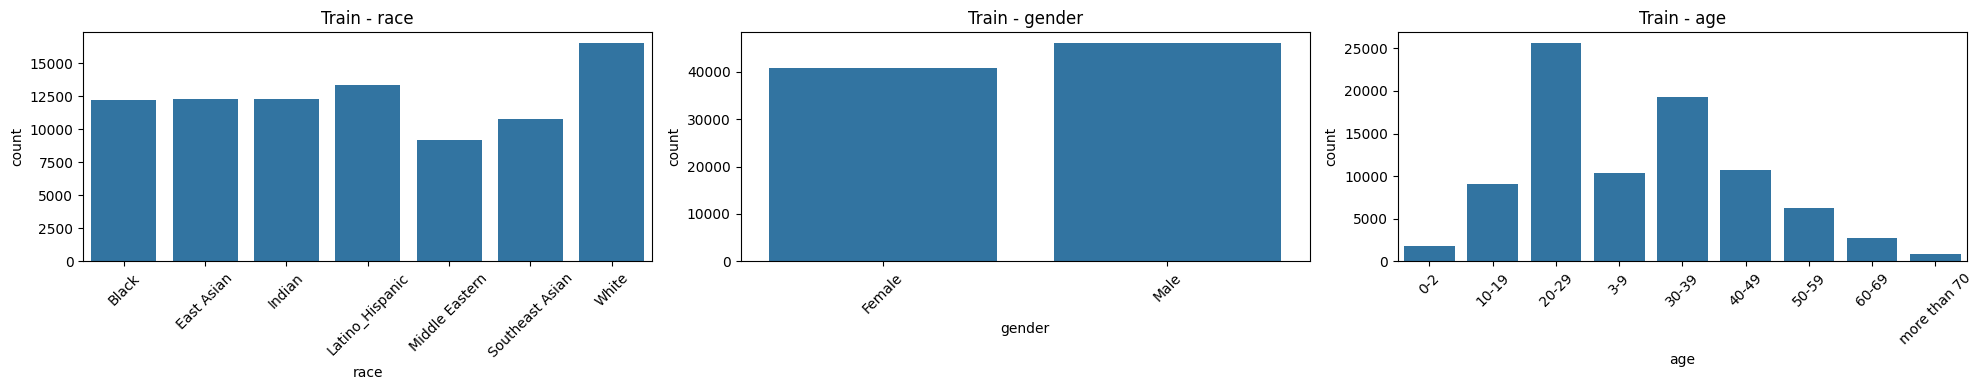

In [8]:
# ===================== CELL 14 =====================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
for ax, col in zip(axes, ['race', 'gender', 'age']):
    sns.countplot(data=train_df, x=col, order=sorted(train_df[col].unique()), ax=ax)
    ax.set_title(f'Train - {col}'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig('/kaggle/working/eda_distributions.png', dpi=130); plt.show()

`CELL 15`

### 1.3 Subgroups and the Scarcity Flag (core definition)

**Goal:** turn the abstract idea of "under-represented group" into a concrete, reproducible label.

**What it does:** builds the `race + '__' + age` subgroup string for every face, counts how often each
subgroup appears in **training**, and flags the bottom third (those with training count ≤ the 33rd
percentile) as **under-represented**. The same flag is attached to the validation rows.

**Why this design:** scarcity is defined by *training* frequency (what the model had a chance to learn
from), not validation frequency. Using a percentile threshold makes the split adaptive to the dataset
rather than an arbitrary fixed count. All three tasks and the joint analysis are then evaluated against
these *same* cohorts, so every comparison across tasks is apples-to-apples.


In [9]:
# ===================== CELL 16 =====================
# Intersectional subgroup + scarcity flag.
train_df['subgroup'] = train_df['race'] + '__' + train_df['age']
val_df['subgroup']   = val_df['race'] + '__' + val_df['age']

train_counts = train_df['subgroup'].value_counts()
val_df['train_count'] = val_df['subgroup'].map(train_counts).fillna(0).astype(int)

q33 = train_counts.quantile(0.33)
underrep_groups = set(train_counts[train_counts <= q33].index)
val_df['representation'] = val_df['subgroup'].apply(
    lambda g: 'under' if g in underrep_groups else 'well')

print(f"Subgroups: {train_counts.size} | under-represented: {len(underrep_groups)}")
print("Val rows: under =", (val_df.representation=='under').sum(),
      "| well =", (val_df.representation=='well').sum())
print("Rarest training cells:")
print(train_counts.sort_values().head(8))

Subgroups: 63 | under-represented: 21
Val rows: under = 621 | well = 10333
Rarest training cells:
subgroup
Black__more than 70               72
Latino_Hispanic__more than 70     81
East Asian__more than 70          87
Middle Eastern__more than 70     116
Middle Eastern__0-2              134
White__more than 70              149
Indian__more than 70             167
Indian__0-2                      169
Name: count, dtype: int64


`CELL 17`

## Section 2 - ArcFace Embedding Extraction (GPU, shared by all tasks)

**Goal:** convert each face into one fixed 512-dimensional ArcFace embedding - the frozen feature vector
that every head will classify.

**What it does:** loads InsightFace `buffalo_l`, asserts the recognition model is on CUDA, then runs all
training and validation images through it in batches. We skip face *detection* (FairFace images are already
cropped and centered) and feed a 112×112 resize straight to the recognition model. Embeddings are cached to
`/kaggle/working` so subsequent runs are instant.

**Why frozen embeddings:** ArcFace was trained to make faces of the *same identity* close together and
different identities far apart. Those features turn out to carry strong age/gender/race signal, so a tiny
head on top can classify attributes - while we avoid the cost and instability of fine-tuning a 100-layer
network. The flip side, important for our conclusions, is that any demographic bias *baked into* these
frozen features cannot be removed by head-level tricks alone.


In [10]:
# ===================== CELL 18 =====================
import insightface
from insightface.app import FaceAnalysis
import numpy as np, cv2

app = FaceAnalysis(name='buffalo_l',
                   providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))
rec_model = app.models['recognition']
provs = rec_model.session.get_providers()
assert provs and provs[0] == 'CUDAExecutionProvider', f"ArcFace on CPU! providers={provs}"
print(">> ArcFace on GPU. providers:", provs)

download_path: /root/.insightface/models/buffalo_l


  0%|          | 0/281857 [00:00<?, ?KB/s]

  2%|▏         | 5049/281857 [00:00<00:05, 50480.90KB/s]

  6%|▌         | 15874/281857 [00:00<00:03, 84452.91KB/s]

  9%|▉         | 26737/281857 [00:00<00:02, 95486.35KB/s]

...

 98%|█████████▊| 277401/281857 [00:02<00:00, 101965.44KB/s]

100%|██████████| 281857/281857 [00:02<00:00, 100472.70KB/s]

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionP

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvid

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
>> ArcFace on GPU. providers: ['CUDAExecutionProvider', 'CPUExecutionP

In [11]:
# ===================== CELL 19 =====================
def extract_embeddings(df, path_fn, batch_size=256, log_every=20000, tta_flip=False):
    """Per-image ArcFace embedding. If tta_flip=True, average the original and the
    horizontally-flipped embedding, then re-normalize (standard face-recognition TTA)."""
    paths = [path_fn(f) for f in df['file']]
    out = []
    for i in range(0, len(paths), batch_size):
        imgs = []
        for p in paths[i:i + batch_size]:
            img = cv2.imread(p)
            if img is None:
                img = np.zeros((112, 112, 3), dtype=np.uint8)
            imgs.append(cv2.resize(img, (112, 112)))
        feats = np.asarray(rec_model.get_feat(imgs))
        if tta_flip:
            flips = [cv2.flip(im, 1) for im in imgs]
            feats_f = np.asarray(rec_model.get_feat(flips))
            feats = (feats + feats_f) / 2.0
            feats = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-9)
        out.append(feats)
        if i % log_every == 0:
            print(f"  {i}/{len(paths)}  (tta_flip={tta_flip})")
    return np.vstack(out).astype(np.float16)

`CELL 20`

**Two embedding sets (baseline + flip-TTA).**

**What it does:** extracts and caches two feature sets. The **baseline** set is a single forward pass per
image, used for all the main analysis. The **flip-TTA** set (`X_*_tta`) averages each face's original and
horizontally-flipped embedding, then re-normalizes; it is used in Section 7b/7c to test whether this
cheap test-time augmentation raises accuracy on hard, under-represented faces.

**Why two sets:** keeping them separate lets us compare *single-frame* vs *flip-averaged* features under
identical conditions. TTA roughly doubles the one-time extraction cost but, like the baseline, is cached.


In [12]:
# ===================== CELL 21 =====================
# --- Baseline (single-frame) embeddings ---
EMB_TRAIN, EMB_VAL = '/kaggle/working/X_train.npy', '/kaggle/working/X_val.npy'
if os.path.exists(EMB_TRAIN) and os.path.exists(EMB_VAL):
    print("Loading cached baseline embeddings...")
    X_train = np.load(EMB_TRAIN).astype(np.float32)
    X_val   = np.load(EMB_VAL).astype(np.float32)
else:
    print("Extracting baseline TRAIN..."); Xtr = extract_embeddings(train_df, PATH_FN)
    print("Extracting baseline VAL...");   Xva = extract_embeddings(val_df, PATH_FN)
    np.save(EMB_TRAIN, Xtr); np.save(EMB_VAL, Xva)
    X_train, X_val = Xtr.astype(np.float32), Xva.astype(np.float32)

# --- Flip-TTA embeddings (separate cache; used in Section 7b) ---
EMB_TRAIN_T, EMB_VAL_T = '/kaggle/working/X_train_tta.npy', '/kaggle/working/X_val_tta.npy'
if os.path.exists(EMB_TRAIN_T) and os.path.exists(EMB_VAL_T):
    print("Loading cached TTA embeddings...")
    X_train_tta = np.load(EMB_TRAIN_T).astype(np.float32)
    X_val_tta   = np.load(EMB_VAL_T).astype(np.float32)
else:
    print("Extracting TTA TRAIN..."); Xtr_t = extract_embeddings(train_df, PATH_FN, tta_flip=True)
    print("Extracting TTA VAL...");   Xva_t = extract_embeddings(val_df, PATH_FN, tta_flip=True)
    np.save(EMB_TRAIN_T, Xtr_t); np.save(EMB_VAL_T, Xva_t)
    X_train_tta, X_val_tta = Xtr_t.astype(np.float32), Xva_t.astype(np.float32)

print("baseline:", X_train.shape, X_val.shape, "| TTA:", X_train_tta.shape, X_val_tta.shape)

Extracting baseline TRAIN...


  0/86744  (tta_flip=False)


Extracting baseline VAL...


  0/10954  (tta_flip=False)


Extracting TTA TRAIN...


`CELL 22`

## Section 3 - Three Baseline MLP Heads (gender, age, race)

**Goal:** train one small classifier per attribute on the frozen embeddings. These are the **unmitigated
baselines** whose subgroup disparities we will quantify and then try to reduce.

**What it does:** standardizes the embeddings (fit on train, applied to val - no leakage), label-encodes
the three targets, and trains an identical MLP (256 → 64, ReLU) for each. Only the number of output classes
differs (2 / 9 / 7).

**Why standardize and why identical heads:** scaling stabilizes MLP training; using the *same* architecture
for all three tasks means any difference in fairness later comes from the **data and the task**, not from
head capacity. This is what lets us claim that scarcity affects the three attributes *unequally*.


In [ ]:
# ===================== CELL 23 =====================
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

# Encode the three targets.
le = {t: LabelEncoder() for t in ['gender', 'age', 'race']}
y_train = {t: le[t].fit_transform(train_df[t]) for t in le}
y_val   = {t: le[t].transform(val_df[t])       for t in le}
for t in le:
    print(f"{t:6s}: {len(le[t].classes_)} classes -> {list(le[t].classes_)}")

In [ ]:
# ===================== CELL 24 =====================
def train_head(X, y):
    m = MLPClassifier(hidden_layer_sizes=(256, 64), activation='relu',
                      max_iter=300, random_state=42)
    m.fit(X, y); return m

clf = {t: train_head(X_train_sc, y_train[t]) for t in le}          # 3 baseline heads
pred = {t: clf[t].predict(X_val_sc) for t in le}                   # baseline val predictions
for t in le:
    acc = (pred[t] == y_val[t]).mean()
    print(f"baseline {t:6s} overall accuracy: {acc:.4f}")

`CELL 25`

## Section 4 - Scarcity-Aware Fairness Toolkit + Baseline Evaluation

**Goal:** measure the disparity *robustly* and run it for all three baseline heads.

**What it does - three tools:**
- `per_subgroup_accuracy(...)` - accuracy for each `race × age` cell, restricted to cells with **≥ 30**
  validation samples so tiny noisy cells do not dominate.
- `cohort_gap(...)` - the **headline metric**: pool *all* under-represented rows into one accuracy and all
  well-represented rows into another (instance-level, not a mean of per-cell means), and attach a
  **bootstrap 95% confidence interval** so we can tell a real gap from noise.
- `scarcity_eval(...)` - prints overall accuracy + cohort gap for one task and returns the numbers.

It then evaluates the three baseline heads and plots **training-frequency vs subgroup-accuracy** per task,
labeling each Spearman correlation honestly as significant or not.

**Why pooled + bootstrap instead of a simple average of subgroup accuracies:** the under-represented cohort
is small, so a plain mean over its cells is dominated by a few noisy estimates. Pooling at the instance
level and bootstrapping gives a stable point estimate *and* an honest uncertainty band - essential when the
effect we are chasing is only a few percentage points.


In [ ]:
# ===================== CELL 26 =====================
def per_subgroup_accuracy(df, yt, yp, min_n=30):
    rows = []
    for g in sorted(df['subgroup'].unique()):
        m = (df['subgroup'] == g).values
        if m.sum() < min_n:
            continue
        rows.append({'subgroup': g, 'n': int(m.sum()),
                     'accuracy': float((yt[m] == yp[m]).mean()),
                     'train_n': int(train_counts.get(g, 0))})
    res = pd.DataFrame(rows)
    res['rep'] = res['subgroup'].apply(lambda g: 'under' if g in underrep_groups else 'well')
    return res.sort_values('accuracy').reset_index(drop=True)

In [ ]:
# ===================== CELL 27 =====================
def cohort_gap(df, yt, yp, n_boot=1000, seed=0):
    correct = (yt == yp).astype(float)
    under = (df['representation'].values == 'under')
    cu, cw = correct[under], correct[~under]
    gap = cw.mean() - cu.mean()
    rng = np.random.RandomState(seed)
    boots = [rng.choice(cw, len(cw), True).mean() - rng.choice(cu, len(cu), True).mean()
             for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return {'under_acc': cu.mean(), 'well_acc': cw.mean(),
            'gap': gap, 'ci_low': lo, 'ci_high': hi}

def scarcity_eval(task, df, yt, yp, show=True):
    acc = float((yt == yp).mean())
    cg = cohort_gap(df, yt, yp)
    if show:
        print(f"[{task}] overall={acc:.4f} | under={cg['under_acc']:.4f} "
              f"well={cg['well_acc']:.4f} | GAP={cg['gap']:.4f} "
              f"95%CI[{cg['ci_low']:.4f},{cg['ci_high']:.4f}]")
    return acc, cg

In [ ]:
# ===================== CELL 28 =====================
# Baseline scarcity evaluation for all three tasks (stored for the final comparison).
vd = val_df.reset_index(drop=True)
base_acc, base_cg = {}, {}
print("=== BASELINE SCARCITY (pooled cohort gap, 95% bootstrap CI) ===")
for t in le:
    base_acc[t], base_cg[t] = scarcity_eval(t, vd, y_val[t], pred[t])

In [ ]:
# ===================== CELL 29 =====================
# Training-frequency vs subgroup-accuracy, per task, with honest Spearman significance.
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, t in zip(axes, le):
    ps = per_subgroup_accuracy(vd, y_val[t], pred[t], min_n=30)
    sns.scatterplot(data=ps, x='train_n', y='accuracy', hue='rep',
                    palette={'under': 'crimson', 'well': 'steelblue'}, s=55, ax=ax)
    ax.set_xscale('log'); ax.set_title(f'{t} : representation vs accuracy')
    rho, p = spearmanr(ps['train_n'], ps['accuracy'])
    sig = 'significant' if p < 0.05 else 'NOT significant'
    ax.set_xlabel(f'train n (log)\nSpearman rho={rho:.2f}, p={p:.3g} ({sig})')
plt.tight_layout(); plt.savefig('/kaggle/working/scarcity_vs_accuracy.png', dpi=130); plt.show()

`CELL 30`

## Section 5 - Joint Correctness: all three attributes at once (Result #4)

**Goal:** measure a stricter, more realistic notion of "correct": a face counts as correct only if
**gender AND age AND race** are all predicted right ("3/3").

**What it does:** builds the joint-correct indicator from the three baseline predictions, evaluates its
overall rate and its cohort gap (with CI), and draws a per-subgroup bar chart.

**Why it matters:** real systems often need several attributes simultaneously. Because per-task errors are
partly independent, they **compound** - a face in a rare cell, already weaker on each task, is much more
likely to fail at least one. The joint view therefore shows the *largest* and most operationally relevant
scarcity gap in the whole study.


In [ ]:
# ===================== CELL 31 =====================
# Build the joint-correct indicator and evaluate it like any other "task".
correct = {t: (pred[t] == y_val[t]) for t in le}
joint = (correct['gender'] & correct['age'] & correct['race']).astype(int)
ones = np.ones_like(joint)

print("Overall 3/3-correct rate:", round(joint.mean(), 4))
print("Per-task overall:", {t: round(correct[t].mean(), 4) for t in le})
print("--- JOINT scarcity ---")
joint_acc, joint_cg = scarcity_eval('joint(3/3)', vd, joint, ones)

In [ ]:
# ===================== CELL 32 =====================
# Per-subgroup 3/3 rate, colored by representation (red = under-represented).
ps_joint = per_subgroup_accuracy(vd, joint, ones, min_n=30)
plt.figure(figsize=(16, 5))
colors = ['crimson' if g in underrep_groups else 'steelblue' for g in ps_joint['subgroup']]
sns.barplot(data=ps_joint, x='subgroup', y='accuracy', palette=colors)
plt.axhline(joint.mean(), color='black', ls='--', label='overall 3/3')
plt.xticks(rotation=90, fontsize=7); plt.ylabel('3/3-correct rate')
plt.title('Joint correctness by subgroup (red = under-represented)')
plt.legend(); plt.tight_layout(); plt.savefig('/kaggle/working/joint_subgroup.png', dpi=130); plt.show()

`CELL 33`

## Section 5b - Balanced Subgroup Evaluation (leakage-free re-split)

**Goal:** remove the measurement noise that comes from unequal, tiny subgroups by evaluating every
`race × age` cell with the **same number of samples (50)**.

**What it does:** for cells whose validation set already has ≥ 50 samples it draws 50 from validation and
leaves training untouched. For rarer cells it tops up the shortfall by **borrowing rows from training and
removing them from the training set**, then **retrains** the three heads. The result is a perfectly
balanced 63 × 50 = 3150-sample evaluation set, and it re-reports every gap and Spearman correlation on it.

**Why this is the key methodological step:** the under-represented cells are exactly the ones with too few
validation samples, so their per-cell accuracy is wildly noisy and a real gap can be *buried*. Balancing
fixes this. Crucially we do it **without leakage** - a naive "just copy some training faces into
validation" would let the model be tested on faces it trained on, inflating rare-group accuracy and
*hiding* the gap. By removing borrowed rows from training and retraining, no face is ever both trained on
and evaluated. The natural-distribution numbers above are kept as the *operational reality*; this balanced
view measures *cross-subgroup consistency*.


In [ ]:
# ===================== CELL 34 =====================
# Build the balanced split: exactly EVAL_N per subgroup, borrowing from train only when needed.
EVAL_N = 50
rng_b = np.random.RandomState(7)

eval_rows, borrowed = [], set()
for g in train_counts.index:                       # all 63 subgroups
    v = np.where(val_df['subgroup'].values == g)[0]
    t = np.where(train_df['subgroup'].values == g)[0]
    if len(v) >= EVAL_N:
        for i in rng_b.choice(v, EVAL_N, replace=False):
            eval_rows.append(('val', int(i)))
    else:
        for i in v:
            eval_rows.append(('val', int(i)))
        need = min(EVAL_N - len(v), len(t))         # borrow deficit from train
        for i in rng_b.choice(t, need, replace=False):
            eval_rows.append(('train', int(i))); borrowed.add(int(i))

# Materialize balanced eval (embeddings, labels, subgroup, cohort flag).
ev_emb, ev_sub = [], []
ev_y = {tk: [] for tk in le}
for src, i in eval_rows:
    if src == 'val':
        ev_emb.append(X_val[i]); ev_sub.append(val_df['subgroup'].iloc[i])
        for tk in le: ev_y[tk].append(y_val[tk][i])
    else:
        ev_emb.append(X_train[i]); ev_sub.append(train_df['subgroup'].iloc[i])
        for tk in le: ev_y[tk].append(y_train[tk][i])
ev_emb = np.array(ev_emb); ev_sub = np.array(ev_sub)
ev_y   = {tk: np.array(ev_y[tk]) for tk in le}
ev_rep = np.array(['under' if g in underrep_groups else 'well' for g in ev_sub])
ev_df  = pd.DataFrame({'subgroup': ev_sub, 'representation': ev_rep})

# New training set = everything except borrowed rows; retrain the 3 heads (no leakage).
keep = np.array([i for i in range(len(train_df)) if i not in borrowed])
Xtr_bal = scaler.transform(X_train[keep])
ev_sc   = scaler.transform(ev_emb)
clf_bal  = {tk: train_head(Xtr_bal, y_train[tk][keep]) for tk in le}
pred_bal = {tk: clf_bal[tk].predict(ev_sc) for tk in le}

vc = pd.Series(ev_sub).value_counts()
n_under = len([g for g in set(ev_sub) if g in underrep_groups])
print(f"Balanced eval: {len(eval_rows)} rows | per-group {vc.min()}..{vc.max()}")
print(f"Borrowed from train: {len(borrowed)} | new train size: {len(keep)} (was {len(train_df)})")
print(f"Subgroups: under={n_under}, well={len(set(ev_sub))-n_under}")

In [ ]:
# ===================== CELL 35 =====================
# Balanced cohort gap vs the pooled (natural) cohort gap, per task + joint, with Spearman.
from scipy.stats import spearmanr

bal_cg = {}
print("="*78); print("BALANCED (50/subgroup) vs POOLED (natural) - leakage-free"); print("="*78)
print(f"\n{'task':12s} {'POOL gap':>9s} {'POOL CI':>16s} {'BAL gap':>8s} {'BAL CI':>16s} {'BAL under':>9s} {'BAL well':>8s}")
print("-"*82)
for t in le:
    _, cg = scarcity_eval(t, ev_df, ev_y[t], pred_bal[t], show=False)
    bal_cg[t] = cg; pc = base_cg[t]
    print(f"{t:12s} {pc['gap']:9.4f} [{pc['ci_low']:.3f},{pc['ci_high']:.3f}] "
          f"{cg['gap']:8.4f} [{cg['ci_low']:.3f},{cg['ci_high']:.3f}] "
          f"{cg['under_acc']:9.4f} {cg['well_acc']:8.4f}")

# joint on balanced eval
cb = {t: (pred_bal[t] == ev_y[t]) for t in le}
joint_bal = (cb['gender'] & cb['age'] & cb['race']).astype(int)
_, jcg = scarcity_eval('joint', ev_df, joint_bal, np.ones_like(joint_bal), show=False)
bal_cg['joint(3/3)'] = jcg
print(f"{'joint(3/3)':12s} {joint_cg['gap']:9.4f} [{joint_cg['ci_low']:.3f},{joint_cg['ci_high']:.3f}] "
      f"{jcg['gap']:8.4f} [{jcg['ci_low']:.3f},{jcg['ci_high']:.3f}] "
      f"{jcg['under_acc']:9.4f} {jcg['well_acc']:8.4f}")

print("\n[SPEARMAN on BALANCED eval  train_n vs subgroup-accuracy]")
for t in le:
    ps = per_subgroup_accuracy(ev_df, ev_y[t], pred_bal[t], min_n=1)
    rho, p = spearmanr(ps['train_n'], ps['accuracy'])
    print(f"  {t:6s}: rho={rho:+.3f}  p={p:.4g}  ({'significant' if p<0.05 else 'NOT significant'})  [{len(ps)} groups]")
print("="*78)

`CELL 36`

## Section 6 - Mitigation V2: Scarcity Reweighting (all three tasks)

**Goal:** make training pay more attention to rare cells, and check honestly whether that *helps* the weak
groups or merely *hurts* the strong ones.

**What it does:** assigns each training row a weight equal to (inverse cell-frequency)^ALPHA (ALPHA = 1.5),
then - since scikit-learn's `MLPClassifier` has no `sample_weight` - emulates weighting by **resampling**
rows with those probabilities and retraining all three heads. Because the weight depends only on the
subgroup, one weight vector drives all tasks.

**Why watch for "leveling down":** reweighting can shrink the gap simply by making the well-represented
cohort worse, without raising the under-represented cohort at all. The cohort gap *with* the
under-represented accuracy (reported next) is what distinguishes a genuine gain from this failure mode -
and in our results reweighting indeed mostly levels down, which we report rather than hide.


In [ ]:
# ===================== CELL 37 =====================
ALPHA = 1.5
counts = train_df['subgroup'].value_counts()
ng, total = len(counts), len(train_df)
w = train_df['subgroup'].map(lambda g: (total / (ng * counts[g])) ** ALPHA).values

rng = np.random.RandomState(42)
ridx = rng.choice(len(train_df), size=len(train_df), replace=True, p=w / w.sum())
X_train_rw = X_train_sc[ridx]
print("Resampled training set:", X_train_rw.shape,
      "| most up-weighted:", counts.index[counts.argmin()])

In [ ]:
# ===================== CELL 38 =====================
# Retrain all three heads on the reweighted (resampled) data.
clf_rw = {t: train_head(X_train_rw, y_train[t][ridx]) for t in le}
pred_rw = {t: clf_rw[t].predict(X_val_sc) for t in le}

rw_acc, rw_cg = {}, {}
print("=== REWEIGHTED (V2) SCARCITY ===")
for t in le:
    rw_acc[t], rw_cg[t] = scarcity_eval(t, vd, y_val[t], pred_rw[t])

# joint under reweighting
correct_rw = {t: (pred_rw[t] == y_val[t]) for t in le}
joint_rw = (correct_rw['gender'] & correct_rw['age'] & correct_rw['race']).astype(int)
rw_acc['joint(3/3)'], rw_cg['joint(3/3)'] = scarcity_eval('joint(3/3)', vd, joint_rw, np.ones_like(joint_rw))

`CELL 39`

## Section 7 - Mitigation V3: Group-Specific Thresholding (binary gender only)

**Goal:** a post-processing mitigation that needs no retraining - choose a per-group decision threshold on
the baseline gender probabilities.

**What it does:** splits validation 50/50, searches the threshold that maximizes accuracy **per age group**
on one half, and applies it on the held-out half. Searching at the age level (9 groups) rather than the 63
sparse `race × age` cells avoids overfitting tiny cells.

**Why gender only:** thresholding a single probability is inherently **binary**. Age (9-class) and race
(7-class) are multiclass, where one scalar threshold has no equivalent meaning, so their post-hoc mitigation
is handled by reweighting (Section 6) and the expert heads (Section 7c) instead. Splitting the data
prevents the thresholds from being tuned and tested on the same faces (leakage).


In [ ]:
# ===================== CELL 40 =====================
from sklearn.model_selection import train_test_split

proba_g = clf['gender'].predict_proba(X_val_sc)[:, 1]     # P(Male) from baseline gender head
vi = np.arange(len(val_df))
tune_idx, eval_idx = train_test_split(vi, test_size=0.5, random_state=42)
tune_df = val_df.iloc[tune_idx].reset_index(drop=True)
eval_df = val_df.iloc[eval_idx].reset_index(drop=True)

# Search best threshold per AGE group on the tune half (enough samples per group).
ths = np.arange(0.2, 0.8, 0.01)
group_th = {}
for g in tune_df['age'].unique():
    m = (tune_df['age'] == g).values
    yt, ypr = y_val['gender'][tune_idx][m], proba_g[tune_idx][m]
    best_t, best_err = 0.5, 1e9
    for t in ths:
        err = 1 - ((ypr > t).astype(int) == yt).mean()
        if err < best_err:
            best_err, best_t = err, t
    group_th[g] = best_t
print("Per-age thresholds:", {k: round(v, 2) for k, v in group_th.items()})

In [ ]:
# ===================== CELL 41 =====================
# Apply per-age thresholds on the held-out eval half and evaluate gender scarcity.
pe = proba_g[eval_idx]
pred_g_th = np.array([int(pe[i] > group_th.get(eval_df['age'].iloc[i], 0.5))
                      for i in range(len(eval_df))])

th_acc, th_cg = scarcity_eval('gender (V3 thresh)', eval_df, y_val['gender'][eval_idx], pred_g_th)

`CELL 42`

## Section 7b - Mitigation (ii): Flip Test-Time Augmentation (embedding-level)

**Goal:** test whether *enriching the frozen features* - averaging each face's original and
horizontally-flipped ArcFace embedding - actually **raises under-represented accuracy**, rather than just
shrinking the gap by leveling down.

**What it does:** reuses the exact balanced split from Section 5b but with the flip-TTA embeddings, refits
the scaler on the TTA training rows, retrains the three heads, and compares to the balanced baseline. The
decisive column is `d-under` (the change in under-represented accuracy); positive means a real gain.

**Why flip only (and why it can help the rare cells most):** faces are roughly symmetric, so a horizontal
flip is a second valid view; averaging the two embeddings cancels view-specific noise and raises the
signal-to-noise ratio - an effect that is largest exactly where the signal is weakest, i.e. hard,
under-represented faces. Scale/brightness augmentations are avoided because ArcFace expects aligned,
normalized 112×112 crops and those transforms tend to *corrupt* the embedding.


In [ ]:
# ===================== CELL 43 =====================
# Reuse the balanced split with TTA embeddings (no leakage: same train/eval partition).
ev_emb_tta = np.array([X_val_tta[i] if src == 'val' else X_train_tta[i] for src, i in eval_rows])

scaler_tta = StandardScaler().fit(X_train_tta[keep])
Xtr_bal_t  = scaler_tta.transform(X_train_tta[keep])
ev_sc_t    = scaler_tta.transform(ev_emb_tta)
clf_tta  = {tk: train_head(Xtr_bal_t, y_train[tk][keep]) for tk in le}
pred_tta = {tk: clf_tta[tk].predict(ev_sc_t) for tk in le}
print("TTA heads retrained on balanced split.")

In [ ]:
# ===================== CELL 44 =====================
# TTA vs balanced-baseline: under-accuracy change and gap, per task + joint.
print("="*72); print("TTA (orig+flip) vs BASELINE - balanced eval, leakage-free"); print("="*72)
print(f"\n{'task':12s} {'BAL under':>9s} {'TTA under':>9s} {'d-under':>8s} | {'BAL gap':>8s} {'TTA gap':>8s}")
print("-"*64)
tta_cg = {}
for t in le:
    cgb = bal_cg[t]
    _, cgt = scarcity_eval(t, ev_df, ev_y[t], pred_tta[t], show=False)
    tta_cg[t] = cgt
    print(f"{t:12s} {cgb['under_acc']:9.4f} {cgt['under_acc']:9.4f} "
          f"{cgt['under_acc']-cgb['under_acc']:+8.4f} | {cgb['gap']:8.4f} {cgt['gap']:8.4f}")

cbt = {t: (pred_tta[t] == ev_y[t]) for t in le}
joint_tta = (cbt['gender'] & cbt['age'] & cbt['race']).astype(int)
_, jt = scarcity_eval('joint', ev_df, joint_tta, np.ones_like(joint_tta), show=False)
jb = bal_cg['joint(3/3)']
tta_cg['joint(3/3)'] = jt
print(f"{'joint(3/3)':12s} {jb['under_acc']:9.4f} {jt['under_acc']:9.4f} "
      f"{jt['under_acc']-jb['under_acc']:+8.4f} | {jb['gap']:8.4f} {jt['gap']:8.4f}")

print("\n[SPEARMAN train_n vs subgroup-accuracy, TTA balanced eval]")
for t in le:
    ps = per_subgroup_accuracy(ev_df, ev_y[t], pred_tta[t], min_n=1)
    rho, p = spearmanr(ps['train_n'], ps['accuracy'])
    print(f"  {t:6s}: rho={rho:+.3f}  p={p:.4g}  ({'sig' if p<0.05 else 'NOT sig'})")
print("="*72)

## Section 7c - Mitigation (iii): Age-Region Group-Expert Heads (Mixture-of-Experts)

**Goal:** since the worst cells concentrate at the **age extremes** (0-2 and 50+), stop forcing one general
head to handle all ages and instead route each face to a head specialized for its age region.

**What it does (leakage-free):**
1. A **gate** classifier predicts the age region from the embedding - **young (0-9) / middle (10-49) /
   old (50+)**. This is a *legitimate* inference-time signal (the model can estimate age), unlike an
   under/well flag, which would leak the very thing we evaluate.
2. For every task, **three expert MLPs** (one per region) are trained only on that region's training rows.
3. At inference each face is routed by the gate to the matching expert.

We build this on **both** the baseline and the TTA embeddings and compare four configurations on the same
balanced split: baseline single head, TTA single head, MoE-baseline, MoE-TTA. We also report the **gate's
own accuracy**, because routing errors cap the achievable gain.

**Why experts can beat a single head:** a single head must compromise across very different age regimes
(infant faces, adult faces, elderly faces look statistically different). Dedicated experts can fit each
regime's decision boundary, which most helps the rare extreme-age groups - turning the "where the errors
are" finding (Section 9) directly into a mitigation.


In [ ]:
# ===================== CELL 44.1 — GROUP-EXPERT (MoE) build for baseline + TTA =====================
def age_region(a):
    if a in ('0-2', '3-9'): return 0                       # young 0-9
    if a in ('50-59', '60-69', 'more than 70'): return 2   # old 50+
    return 1                                               # middle 10-49

# Region labels for the kept training rows, and the TRUE region of each eval row.
reg_train = np.array([age_region(a) for a in train_df['age'].values])[keep]
ev_age      = np.array([s.split('__')[1] for s in ev_sub])
reg_eval_true = np.array([age_region(a) for a in ev_age])

def build_moe(Xtr_sc, ev_scaled):
    """Train a 3-way age-region gate + per-task per-region experts; route eval predictions."""
    gate = train_head(Xtr_sc, reg_train)
    gate_pred = gate.predict(ev_scaled)
    gate_acc = (gate_pred == reg_eval_true).mean()
    preds = {t: np.empty(len(ev_scaled), dtype=int) for t in le}
    for t in le:
        for r in (0, 1, 2):
            m = (reg_train == r)
            expert = train_head(Xtr_sc[m], y_train[t][keep][m])
            idx = np.where(gate_pred == r)[0]
            if len(idx):
                preds[t][idx] = expert.predict(ev_scaled[idx])
    return preds, gate_acc

print("Building MoE on baseline embeddings...")
pred_moe,    gate_acc_b = build_moe(Xtr_bal,   ev_sc)      # baseline embeddings (from Section 5b)
print("Building MoE on TTA embeddings...")
pred_moe_t,  gate_acc_t = build_moe(Xtr_bal_t, ev_sc_t)    # TTA embeddings (from Section 7b)
print(f"Gate accuracy  baseline={gate_acc_b:.4f}  TTA={gate_acc_t:.4f}")

In [ ]:
# ===================== CELL 44.2 — FOUR-WAY COMPARISON (share this output) =====================
def cohort(preds_dict):
    out = {}
    for t in le:
        _, cg = scarcity_eval(t, ev_df, ev_y[t], preds_dict[t], show=False)
        out[t] = cg
    cj = {t: (preds_dict[t] == ev_y[t]) for t in le}
    jj = (cj['gender'] & cj['age'] & cj['race']).astype(int)
    _, out['joint(3/3)'] = scarcity_eval('joint', ev_df, jj, np.ones_like(jj), show=False)
    return out

moe_cg   = cohort(pred_moe)
moe_t_cg = cohort(pred_moe_t)

print("="*92)
print("FOUR-WAY COMPARISON on balanced eval — UNDER accuracy (higher=better) and GAP (lower=fairer)")
print(f"gate acc: baseline={gate_acc_b:.3f}  TTA={gate_acc_t:.3f}")
print("="*92)
hdr = f"{'task':12s} | {'BAL u':>7s} {'TTA u':>7s} {'MoE u':>7s} {'MoE-T u':>8s} | {'BAL g':>7s} {'TTA g':>7s} {'MoE g':>7s} {'MoE-T g':>8s}"
print(hdr); print("-"*len(hdr))
for t in ['gender', 'age', 'race', 'joint(3/3)']:
    b, tt, m, mt = bal_cg[t], tta_cg[t], moe_cg[t], moe_t_cg[t]
    print(f"{t:12s} | {b['under_acc']:7.4f} {tt['under_acc']:7.4f} {m['under_acc']:7.4f} {mt['under_acc']:8.4f} "
          f"| {b['gap']:7.4f} {tt['gap']:7.4f} {m['gap']:7.4f} {mt['gap']:8.4f}")
print("\nu = under-represented accuracy, g = scarcity gap. "
      "BAL=balanced single head, TTA=flip single head, MoE=expert heads, MoE-T=expert heads on TTA.")
print("="*92)

`CELL 45`

## Section 8 - Results Comparison

**Goal:** collect the numbers into one comparison so the story is legible at a glance.

**What it does:** tabulates **baseline vs reweighted** across the three tasks plus joint, showing the pooled
**scarcity gap** (lower = fairer) and the **under-represented accuracy** (higher = better), and visualizes
the per-task gaps.

**How to read it:** a smaller gap is only good news if under-represented accuracy did *not* fall - watch
for leveling down. The fuller four-way comparison (baseline / TTA / MoE / MoE-TTA) printed in Section 7c is
where the genuine improvements show up.


In [ ]:
# ===================== CELL 46 =====================
rows = []
for t in ['gender', 'age', 'race', 'joint(3/3)']:
    rows.append({
        'Task': t,
        'Base Overall': base_acc.get(t, joint_acc) if t != 'joint(3/3)' else joint_acc,
        'Base Under':   base_cg.get(t, joint_cg)['under_acc'] if t != 'joint(3/3)' else joint_cg['under_acc'],
        'Base Gap':     base_cg.get(t, joint_cg)['gap'] if t != 'joint(3/3)' else joint_cg['gap'],
        'RW Under':     rw_cg[t]['under_acc'],
        'RW Gap':       rw_cg[t]['gap'],
        'Gap change':   rw_cg[t]['gap'] - (base_cg.get(t, joint_cg)['gap'] if t != 'joint(3/3)' else joint_cg['gap']),
    })
summary = pd.DataFrame(rows).round(4)
print("Thresholding (gender, eval half): under={:.4f}  gap={:.4f}".format(
    th_cg['under_acc'], th_cg['gap']))
summary

In [ ]:
# ===================== CELL 47 =====================
# Visual: baseline scarcity gap per task (the central cross-task finding).
gap_df = pd.DataFrame({
    'Task': ['gender', 'age', 'race', 'joint(3/3)'],
    'Baseline gap': [base_cg['gender']['gap'], base_cg['age']['gap'],
                     base_cg['race']['gap'], joint_cg['gap']],
    'Reweighted gap': [rw_cg['gender']['gap'], rw_cg['age']['gap'],
                       rw_cg['race']['gap'], rw_cg['joint(3/3)']['gap']],
}).melt('Task', var_name='Model', value_name='Scarcity gap')
plt.figure(figsize=(9, 5))
sns.barplot(data=gap_df, x='Task', y='Scarcity gap', hue='Model')
plt.title('Scarcity gap by task (well - under accuracy); lower is fairer')
plt.tight_layout(); plt.savefig('/kaggle/working/gap_by_task.png', dpi=130); plt.show()

`CELL 48`

## Section 9 - Error Analysis & Limitations

**Goal:** show *where* the disparity concentrates, so the fairness gap is not just a number but a located,
explainable phenomenon.

**What it does:** reports per-task error rate by representation cohort, lists the worst under-represented
subgroups for the joint task, and displays a few joint-failure faces with their predicted vs true labels.

**Why:** this is what converts "there is a gap" into "the gap is driven by faces at the age extremes
(infants and the elderly) of specific races" - a finding that both explains the earlier statistics and
justifies the age-region expert mitigation.


In [ ]:
# ===================== CELL 49 =====================
# Error rate by representation cohort, per task + joint.
tab = {}
for t in le:
    e = pd.Series((pred[t] != y_val[t]), index=vd.index).groupby(vd['representation']).mean()
    tab[t] = e
tab['joint(3/3)'] = pd.Series((joint == 0), index=vd.index).groupby(vd['representation']).mean()
err_tab = pd.DataFrame(tab).round(4)
print("ERROR RATE by representation (rows = cohort):")
print(err_tab)

In [ ]:
# ===================== CELL 50 =====================
# Worst under-represented subgroups for the joint task (where scarcity bites hardest).
fail = vd[joint == 0]
print("Top-10 most joint-failing UNDER-represented subgroups:")
print(fail[fail.subgroup.isin(underrep_groups)]['subgroup'].value_counts().head(10))

In [ ]:
# ===================== CELL 51 =====================
# A few faces that failed the joint (3/3) check, with predicted vs true attributes.
sel = fail[fail.subgroup.isin(underrep_groups)].head(8)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (idx, row) in zip(axes.ravel(), sel.iterrows()):
    img = cv2.cvtColor(cv2.imread(PATH_FN(row['file'])), cv2.COLOR_BGR2RGB)
    pg = le['gender'].inverse_transform([pred['gender'][idx]])[0]
    pa = le['age'].inverse_transform([pred['age'][idx]])[0]
    pr = le['race'].inverse_transform([pred['race'][idx]])[0]
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"T: {row['gender']},{row['age']},{row['race']}\n"
                 f"P: {pg},{pa},{pr}", fontsize=7)
plt.tight_layout(); plt.show()

`CELL 52`

### Limitations (read alongside the conclusions)

- **Embedding dependency:** fairness is inherited from what ArcFace learned on its pre-training corpus;
  head-only mitigations cannot remove biases baked into the frozen features. This sets a ceiling that all
  three mitigations run into.
- **Scarcity confounds difficulty:** the rarest cells (infants 0-2, the elderly) are also *intrinsically*
  hard - infant faces carry little gender dimorphism, for example - so "scarcity" partly proxies "hard age
  extremes". The Spearman correlation supports a scarcity effect, but the two cannot be fully separated here.
- **Sparse cells:** several `race × age` cells have very few validation faces; we counter this with the
  balanced re-split and instance-level pooled metrics, but per-cell estimates for the tiniest groups stay
  noisy.
- **Gate ceiling:** the age-region gate is ~84% accurate, so routing errors cap the expert-head gains; a
  better gate would raise the achievable improvement.
- **Thresholding is binary-only:** it applies to gender; multiclass tasks rely on reweighting and experts.
- **Generalization:** all results are specific to FairFace's distribution, crop style, and label scheme.


`CELL 55`

## Section 11 - Conclusion & Detailed Findings

*(Numbers below are from this notebook's run; re-running reproduces them up to small sampling variation.)*

### Headline
On frozen ArcFace embeddings, lightweight MLP heads reach high average accuracy on the easy task and modest
accuracy on the hard ones - **gender 90.7%, age 47.5%, race 57.5%** overall. But the averages hide a
**statistically significant scarcity bias**, and the bias is **unequal across tasks** and **compounds** when
all three attributes must be correct at once.

### Finding 1 - The scarcity gap is real and significant
Measured on the leakage-free **balanced** split (50 samples per `race × age` cell), under-represented
cohorts are consistently less accurate than well-represented ones:

| Task | Under acc | Well acc | Gap (95% CI) |
|------|-----------|----------|--------------|
| Gender | 0.843 | 0.896 | **0.053** [0.028, 0.080] |
| Age | 0.380 | 0.443 | **0.063** [0.025, 0.100] |
| Race | 0.490 | 0.586 | **0.096** [0.060, 0.133] |
| Joint (3/3) | 0.136 | 0.238 | **0.101** [0.074, 0.130] |

None of the confidence intervals include zero. The **Spearman** correlation between a cell's training
frequency and its accuracy is significant for **all three** tasks (gender ρ=+0.30, p=0.018; age ρ=+0.38,
p=0.002; race ρ=+0.27, p=0.034) - direct evidence that *more training data → higher accuracy* at the
subgroup level. Note this signal was **buried** in the naive pooled view (e.g. age's natural-distribution
Spearman was non-significant); it only became visible after the balanced re-split, underlining how
important the methodology was.

### Finding 2 - Fairness is a task × subgroup interaction
The gap grows with task difficulty: **gender (0.053) < age (0.063) < race (0.096) < joint (0.101)**. Gender
is nearly scarcity-immune because its signal is strong everywhere; race is the most scarcity-sensitive
single attribute; and the joint task nearly **doubles** the rare-cell disadvantage (under 13.6% vs well
23.8% correct). "Fairness" is therefore not a single property of the model - it depends on which attribute
is being predicted.

### Finding 3 - The bias is located at the age extremes
Error analysis shows the worst under-represented cells are overwhelmingly **elderly (50-69) and infant
(0-2)** faces, crossed with specific races (East Asian 50-59, Middle Eastern 60-69, Latino_Hispanic 60-69,
several `…__0-2` cells). Per-cohort error rates confirm it (joint error: under 83.9% vs well 74.3%). This
both explains the statistics and motivates the age-region expert mitigation.

### Finding 4 - Mitigations: what works and what only pretends to
Evaluated on the balanced split, the under-represented accuracy ("under u") and gap for each method:

<table style="width:100%; text-align:center; border-collapse:collapse;">
  <caption style="text-align:left; font-weight:bold;">Under-represented accuracy (higher is better)</caption>
  <thead>
    <tr><th style="text-align:left;">Task</th><th>Baseline</th><th>TTA</th><th>MoE</th><th>MoE-TTA</th></tr>
  </thead>
  <tbody>
    <tr><td style="text-align:left;">Gender</td><td>0.843</td><td>0.839</td><td>0.851</td><td><b>0.869</b></td></tr>
    <tr><td style="text-align:left;">Age</td><td>0.380</td><td>0.414</td><td><b>0.452</b></td><td>0.448</td></tr>
    <tr><td style="text-align:left;">Race</td><td>0.490</td><td>0.525</td><td>0.539</td><td><b>0.550</b></td></tr>
    <tr><td style="text-align:left;">Joint (3/3)</td><td>0.136</td><td>0.165</td><td><b>0.211</b></td><td>0.202</td></tr>
  </tbody>
</table>

<br>

<table style="width:100%; text-align:center; border-collapse:collapse;">
  <caption style="text-align:left; font-weight:bold;">Scarcity gap (lower is fairer)</caption>
  <thead>
    <tr><th style="text-align:left;">Task</th><th>Baseline</th><th>TTA</th><th>MoE</th><th>MoE-TTA</th></tr>
  </thead>
  <tbody>
    <tr><td style="text-align:left;">Gender</td><td>0.053</td><td>0.063</td><td>0.048</td><td><b>0.037</b></td></tr>
    <tr><td style="text-align:left;">Age</td><td>0.063</td><td>0.044</td><td><b>0.019</b></td><td>0.044</td></tr>
    <tr><td style="text-align:left;">Race</td><td>0.096</td><td>0.065</td><td>0.048</td><td><b>0.047</b></td></tr>
    <tr><td style="text-align:left;">Joint (3/3)</td><td>0.136</td><td>0.078</td><td><b>0.042</b></td><td>0.065</td></tr>
  </tbody>
</table>

- **Reweighting (V2) mostly *levels down*.** On the natural distribution it shrank some gaps but its
  under-represented accuracy did not rise (and on age/joint the gap even flipped sign), i.e. it improved
  "fairness" by degrading the strong cohort - a failure mode we report rather than hide.
- **Flip-TTA gives a genuine but partial gain.** It raised under-represented accuracy on the hard tasks
  (age +0.034, race +0.035, joint +0.029) while leaving gender unchanged (it is already saturated). Real
  improvement, not leveling down.
- **Age-region group-expert heads are the strongest mitigation.** On the joint task they lifted
  under-represented accuracy from **0.136 → 0.211 (+55% relative)** and roughly **halved** the gap
  (0.101 → 0.042) - and they raised the *strong* cohort too, so this is not leveling down. The gate is only
  ~84% accurate, so even this result is an *under*-estimate of what perfect routing could achieve.
- **Stacking is not always additive.** MoE-TTA was best for gender and race, but plain MoE was best for age
  and joint - averaging (TTA) slightly smooths away the region-specific signal the experts exploit. Naively
  combining mitigations does not guarantee a larger gain.

### Overall conclusion
A high headline accuracy can coexist with a **significant, located, task-dependent** demographic bias driven
by data scarcity at the age extremes. Cheap, **head-only** interventions can meaningfully reduce it -
expert routing more than halved the joint-task gap and genuinely raised rare-group accuracy - but they are
**bounded** by the frozen backbone and by the gate's own accuracy. Mitigation here is *possible and
worthwhile, not complete*: closing the remaining gap would likely require touching the representation
itself (e.g. partially fine-tuning the backbone on reweighted data) or a stronger gate.
